In [1]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F


from transformers import AutoTokenizer, RobertaModel
from transformers import get_linear_schedule_with_warmup
from torch.optim import AdamW

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import mean_absolute_error, mean_squared_error, cohen_kappa_score
from scipy.stats import pearsonr

from tqdm import tqdm

In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BATCH_SIZE = 16
EPOCHS = 10
PATIENCE = 3
LEARNING_RATE = 2e-5
MAX_LENGTH = 512
RANDOM_SEED = 42
WARMUP_RATIO = 0.1

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Device:", DEVICE)

Device: cuda


In [3]:
df = pd.read_csv(
    "task2_cleaned_final.csv",
    engine="python",
    on_bad_lines="skip"
)
df

criteria_cols = [
    "Task_Response",
    "Coherence_Cohesion",
    "Lexical_Resource",
    "Range_Accuracy"
]

features = [
    "length",
    "unique_words",
    "ttr",
    "avg_word_len",
    "sentence_count",
    "avg_sentence_len",
    "sentence_len_var",
    "long_word_ratio",
    "short_word_ratio",
    "punct_density",
]

df = df.dropna(subset=criteria_cols + ["Essay"]).reset_index(drop=True)

print("Total essays:", len(df))

Total essays: 8748


In [4]:
df[criteria_cols] = df[criteria_cols] / 9.0

criteria = torch.tensor(df[criteria_cols].values, dtype=torch.float32)

In [5]:
tokenizer = AutoTokenizer.from_pretrained("FacebookAI/roberta-large")

texts = [
    str(q).strip() + " </s> </s> " + str(e).strip()
    for q, e in zip(df["Question"], df["Essay"])
]

encoded = tokenizer(
    texts,
    padding=True,
    truncation=True,
    max_length=MAX_LENGTH,
    return_tensors="pt"
)
input_ids = encoded["input_ids"]
attention_mask = encoded["attention_mask"]



config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [6]:
idx = np.arange(len(df))

train_idx, temp_idx = train_test_split(
    idx,
    test_size=0.3,
    random_state=RANDOM_SEED,
    shuffle=True
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=2/3,
    random_state=RANDOM_SEED
)

print(len(train_idx), len(val_idx), len(test_idx))

6123 875 1750


In [7]:
scaler = StandardScaler()
df[features] = df[features].astype(float)

df_features = df[features].copy()

df.loc[train_idx, features] = scaler.fit_transform(df.loc[train_idx, features])
df.loc[val_idx, features] = scaler.transform(df.loc[val_idx, features])
df.loc[test_idx, features] = scaler.transform(df.loc[test_idx, features])

feat_tensor = torch.tensor(df[features].values, dtype=torch.float32)

In [8]:
train_dataset = TensorDataset(
    input_ids[train_idx],
    attention_mask[train_idx],
    criteria[train_idx],
    feat_tensor[train_idx]
)

val_dataset = TensorDataset(
    input_ids[val_idx],
    attention_mask[val_idx],
    criteria[val_idx],
    feat_tensor[val_idx]
)

test_dataset = TensorDataset(
    input_ids[test_idx],
    attention_mask[test_idx],
    criteria[test_idx],
    feat_tensor[test_idx]
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

In [9]:
class RobertaLargeIELTS(nn.Module):
    def __init__(self, feature_dim):
        super().__init__()

        self.roberta = RobertaModel.from_pretrained("FacebookAI/roberta-large")
        hidden_size = self.roberta.config.hidden_size   # 1024

        self.feature_encoder = nn.Sequential(
            nn.LayerNorm(feature_dim),
            nn.Linear(feature_dim, 128),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.GELU()
        )

        self.fc = nn.Sequential(
            nn.Linear(hidden_size * 2 + 64, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(0.4),

            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.4)
        )

        self.head_tr = nn.Sequential(
            nn.Linear(256, 64),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

        self.head_cc = nn.Sequential(
            nn.Linear(256, 64),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

        self.head_lr = nn.Sequential(
            nn.Linear(256, 64),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

        self.head_ga = nn.Sequential(
            nn.Linear(256, 64),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def mean_pooling(self, last_hidden, mask):
        mask_expanded = mask.unsqueeze(-1).expand(last_hidden.size()).float()
        sum_hidden = torch.sum(last_hidden * mask_expanded, dim=1)
        sum_mask = torch.clamp(mask_expanded.sum(dim=1), min=1e-9)
        return sum_hidden / sum_mask

    def max_pooling(self, last_hidden, mask):
        mask_expanded = mask.unsqueeze(-1).expand(last_hidden.size()).float()
        masked_hidden = last_hidden.masked_fill(mask_expanded == 0, -1e9)
        return torch.max(masked_hidden, dim=1).values

    def forward(self, ids, mask, features):
        outputs = self.roberta(input_ids=ids, attention_mask=mask)
        last_hidden = outputs.last_hidden_state

        mean_embed = self.mean_pooling(last_hidden, mask)
        max_embed = self.max_pooling(last_hidden, mask)
        text_embed = torch.cat([mean_embed, max_embed], dim=1)

        feat_embed = self.feature_encoder(features)

        x = torch.cat([text_embed, feat_embed], dim=1)
        x = self.fc(x)

        tr = self.head_tr(x)
        cc = self.head_cc(x)
        lr = self.head_lr(x)
        ga = self.head_ga(x)

        crit = torch.cat([tr, cc, lr, ga], dim=1)
        return crit

In [10]:
def freeze_roberta(model):
    for param in model.roberta.parameters():
        param.requires_grad = False

def unfreeze_last_n_layers(model, n_last=2):
    for param in model.roberta.parameters():
        param.requires_grad = False

    for layer in model.roberta.encoder.layer[-n_last:]:
        for param in layer.parameters():
            param.requires_grad = True

def build_optimizer(model, encoder_lr, head_lr):
    encoder_params = []
    head_params = []

    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue

        if name.startswith("roberta"):
            encoder_params.append(param)
        else:
            head_params.append(param)

    param_groups = []

    if len(encoder_params) > 0:
        param_groups.append({
            "params": encoder_params,
            "lr": encoder_lr,
            "weight_decay": 0.01
        })

    if len(head_params) > 0:
        param_groups.append({
            "params": head_params,
            "lr": head_lr,
            "weight_decay": 0.01
        })

    return AdamW(param_groups)

In [11]:
def compute_loss(pred, target, beta=0.05):
    pred_overall = pred.mean(dim=1)
    true_overall = target.mean(dim=1)

    loss_crit = F.smooth_l1_loss(pred, target, beta=beta)
    loss_overall = F.l1_loss(pred_overall, true_overall)

    loss = 0.7 * loss_crit + 0.3 * loss_overall
    return loss

In [12]:
model = RobertaLargeIELTS(feature_dim=feat_tensor.shape[1]).to(DEVICE)

freeze_roberta(model)

optimizer = build_optimizer(
    model,
    encoder_lr=1e-5,
    head_lr=LEARNING_RATE
)

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: FacebookAI/roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [13]:
total_steps = len(train_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(WARMUP_RATIO * total_steps),
    num_training_steps=total_steps
)

In [14]:
best_val = float("inf")
patience_counter = 0

train_losses = []
val_losses = []

logs = []

In [15]:
for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    if epoch == 1:
        print("Unfreeze last 2 layers")
        unfreeze_last_n_layers(model, n_last=2)

        optimizer = build_optimizer(
            model,
            encoder_lr=8e-6,
            head_lr=3e-5
        )

        remaining_steps = len(train_loader) * (EPOCHS - epoch)

        scheduler = get_linear_schedule_with_warmup(
            optimizer,
            num_warmup_steps=int(WARMUP_RATIO * remaining_steps),
            num_training_steps=remaining_steps
        )

    elif epoch == 4:
        print("Unfreeze last 4 layers")
        unfreeze_last_n_layers(model, n_last=4)

        optimizer = build_optimizer(
            model,
            encoder_lr=5e-6,
            head_lr=2e-5
        )

        remaining_steps = len(train_loader) * (EPOCHS - epoch)

        scheduler = get_linear_schedule_with_warmup(
            optimizer,
            num_warmup_steps=int(WARMUP_RATIO * remaining_steps),
            num_training_steps=remaining_steps
        )

    model.train()
    train_loss = 0.0

    for ids, mask, crit, feat in tqdm(train_loader):
        ids = ids.to(DEVICE)
        mask = mask.to(DEVICE)
        crit = crit.to(DEVICE)
        feat = feat.to(DEVICE)

        optimizer.zero_grad()

        pred = model(ids, mask, feat)
        loss = compute_loss(pred, crit, beta=0.05)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        scheduler.step()

        train_loss += loss.item()

    avg_train = train_loss / len(train_loader)

    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for ids, mask, crit, feat in val_loader:
            ids = ids.to(DEVICE)
            mask = mask.to(DEVICE)
            crit = crit.to(DEVICE)
            feat = feat.to(DEVICE)

            pred = model(ids, mask, feat)
            loss = compute_loss(pred, crit, beta=0.05)

            val_loss += loss.item()

    avg_val = val_loss / len(val_loader)

    print(f"Train Loss: {avg_train}")
    print(f"Val Loss:   {avg_val}")

    train_losses.append(avg_train)
    val_losses.append(avg_val)

    logs.append({
        "epoch": epoch + 1,
        "train_loss": avg_train,
        "val_loss": avg_val
    })

    if avg_val < best_val:
        best_val = avg_val
        patience_counter = 0

        torch.save(model.state_dict(), "roberta_large_model.pt")
        print("Saved best model")

    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print("Early stopping")
            break


Epoch 1/10


100%|██████████| 383/383 [00:40<00:00,  9.37it/s]


Train Loss: 0.2837498391110343
Val Loss:   0.09713673191991719
Saved best model

Epoch 2/10
Unfreeze last 2 layers


100%|██████████| 383/383 [00:46<00:00,  8.19it/s]


Train Loss: 0.131764861120412
Val Loss:   0.0897539883852005
Saved best model

Epoch 3/10


...

Train Loss: 0.08990517497918625
Val Loss:   0.076075129956007

Epoch 9/10


100%|██████████| 383/383 [00:53<00:00,  7.13it/s]


Train Loss: 0.0882266091168238
Val Loss:   0.07571983737024394
Saved best model

Epoch 10/10


100%|██████████| 383/383 [00:53<00:00,  7.12it/s]


Train Loss: 0.08723013140942036
Val Loss:   0.07531375925649296
Saved best model


In [16]:
log_df = pd.DataFrame(logs)

log_df.to_csv(
    "roberta_large_traininglogs.csv",
    index=False
)

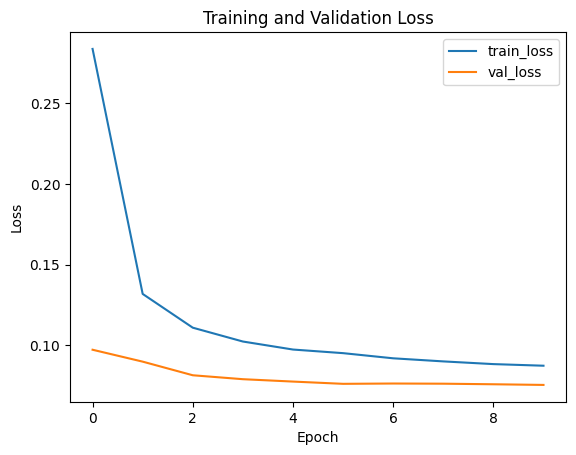

In [17]:
plt.plot(train_losses, label="train_loss")
plt.plot(val_losses, label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()


In [18]:
model.load_state_dict(torch.load("roberta_large_model.pt", map_location=DEVICE))
model.eval()

RobertaLargeIELTS(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 1024, padding_idx=1)
      (token_type_embeddings): Embedding(1, 1024)
      (LayerNorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 1024, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-23): 24 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=1024, out_features=1024, bias=True)
              (key): Linear(in_features=1024, out_features=1024, bias=True)
              (value): Linear(in_features=1024, out_features=1024, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=1024, out_features=1024, bias=True)
              (L

In [19]:
preds = []
trues = []

model.eval()

with torch.no_grad():
    for ids, mask, crit, feat_batch in test_loader:
        ids = ids.to(DEVICE)
        mask = mask.to(DEVICE)
        feat_batch = feat_batch.to(DEVICE)

        crit_pred = model(ids, mask, feat_batch)

        preds.append(crit_pred.cpu().numpy())
        trues.append(crit.cpu().numpy())

pred = np.vstack(preds)
true = np.vstack(trues)

pred = np.clip(pred, 0.0, 1.0) * 9.0
true = true * 9.0

pred_overall = pred.mean(axis=1)
true_overall = true.mean(axis=1)

In [20]:
mae = mean_absolute_error(true_overall, pred_overall)

rmse = np.sqrt(mean_squared_error(true_overall, pred_overall))

pearson = pearsonr(true_overall, pred_overall)[0]

rounded_preds = np.round(pred_overall * 2) / 2
within_half = np.mean(np.abs(rounded_preds - true_overall) <= 0.5)

true_band = np.round(true_overall * 2).astype(int)
pred_band = np.round(pred_overall * 2).astype(int)

qwk = cohen_kappa_score(true_band, pred_band, weights="quadratic")

print("\nTEST RESULTS")
print("MAE:", mae)
print("RMSE:", rmse)
print("Pearson:", pearson)
print("Within ±0.5:", within_half)
print("QWK:", qwk)


TEST RESULTS
MAE: 0.7975193858146667
RMSE: 1.0472629454598728
Pearson: 0.5214317
Within ±0.5: 0.5165714285714286
QWK: 0.428455998272649


In [21]:
def ielts_round(score):

    integer = int(score)
    decimal = score - integer

    if decimal < 0.25:
        return integer
    elif decimal <= 0.5:
        return integer + 0.5
    elif decimal < 0.75:
        return integer + 0.5
    else:
        return integer + 1

In [22]:
def predict_score_task2(question, essay):
    model.eval()

    text = essay.lower()

    tokens = re.findall(r'\b\w+\b', text)
    word_count = len(tokens)
    unique_words = len(set(tokens))
    ttr = unique_words / word_count if word_count > 0 else 0

    avg_word_len = np.mean([len(w) for w in tokens]) if word_count > 0 else 0

    sentences = re.split(r'[.!?]+', essay)
    sentences = [s for s in sentences if s.strip() != ""]

    sentence_count = len(sentences)
    avg_sentence_len = word_count / sentence_count if sentence_count > 0 else 0
    sentence_len_var = np.var([len(s.split()) for s in sentences]) if sentence_count > 0 else 0

    long_word_ratio = np.mean([len(w) > 6 for w in tokens]) if word_count > 0 else 0
    short_word_ratio = np.mean([len(w) <= 3 for w in tokens]) if word_count > 0 else 0

    punct_count = len(re.findall(r'[,.!?;:]', essay))
    punct_density = punct_count / word_count if word_count > 0 else 0

    feature_vector = [[
        word_count,
        unique_words,
        ttr,
        avg_word_len,
        sentence_count,
        avg_sentence_len,
        sentence_len_var,
        long_word_ratio,
        short_word_ratio,
        punct_density
    ]]

    feature_vector = scaler.transform(feature_vector)
    feat_tensor = torch.tensor(feature_vector, dtype=torch.float32).to(DEVICE)

    encoded = tokenizer(
        [str(question)],
        [str(essay)],
        padding=True,
        truncation="only_second",
        max_length=MAX_LENGTH,
        return_tensors="pt"
    )

    ids = encoded["input_ids"].to(DEVICE)
    mask = encoded["attention_mask"].to(DEVICE)

    with torch.no_grad():
        crit = model(ids, mask, feat_tensor)

    crit = crit.squeeze(0).cpu().numpy()

    crit = np.clip(crit, 0.0, 1.0) * 9.0
    overall = np.mean(crit)

    return {
        "Task_Response": float(crit[0]),
        "Coherence_Cohesion": float(crit[1]),
        "Lexical_Resource": float(crit[2]),
        "Range_Accuracy": float(crit[3]),
        "Overall": float(ielts_round(overall))
    }

In [23]:
question = "It is a natural process for animal species to become extinct (e.g. Dinosaur, dodos …) There is no reason why people should try to prevent this from happening. Do you agree or disagree?"

essay = """
Some people believe that there are no compelling reasons for us to protect animal species from extinction as it occurs naturally. I personally disagree with this conviction and will support my argument in the essay below.

It is true that millions of years ago, many ancient species of animals, such as dinosaurs, were wiped out due to a gradual shift in climate and changing sea levels, according to some hypotheses. However, these environmental factors are not the primary contributor to the disappearance of certain species nowadays. Industrial activities have been devastating the natural habitats of wildlife and disturbing the food chain, causing the mass extinction of countless species. The increased demand for goods made from animals’ products, such as skins and horns, also leads to the rampant poaching of wild, endangered animals, rhinos for instance. In this regard, humans are held accountable and should do what is needed to rectify the situation.

Other justifications for saving wild animals involve the significant roles that they play in not only the balance of the ecosystem but also our lives. Everything in nature is connected, and if one species becomes extinct, many other animals and even plants will suffer as the food chain is disrupted. Wild animals also have great aesthetic and socio-cultural values. They contribute to our rich bio-diversity that makes this planet a beautiful place. In numerous places around the world, many types of animals play an important role in different cultures. For example, in some religions, cows are revered and worshiped as gods.

The disappearance of many animal species does not always occur as a natural process but as a consequence of our doings. It is our obligation to help preserve wild animals because their extinction will have a severe influence on many important aspects of our lives.
"""

result7 = predict_score_task2(question, essay)

for k, v in result7.items():
    print(k, ":", v)


Task_Response : 7.159144878387451
Coherence_Cohesion : 7.384232997894287
Lexical_Resource : 7.0450239181518555
Range_Accuracy : 6.967469692230225
Overall : 7.0


/venv/main/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


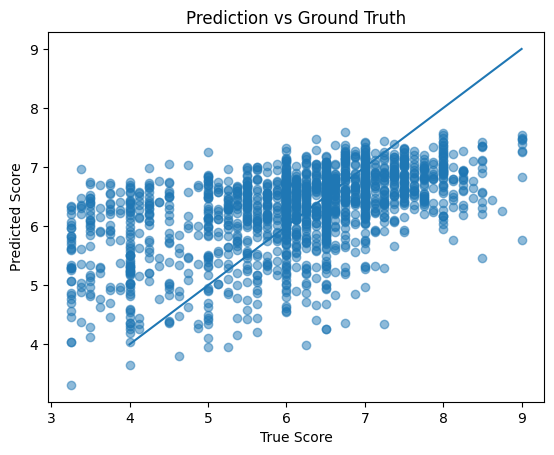

In [24]:
plt.scatter(true_overall, pred_overall, alpha=0.5)
plt.plot([4,9], [4,9])  

plt.xlabel("True Score")
plt.ylabel("Predicted Score")
plt.title("Prediction vs Ground Truth")
plt.show()

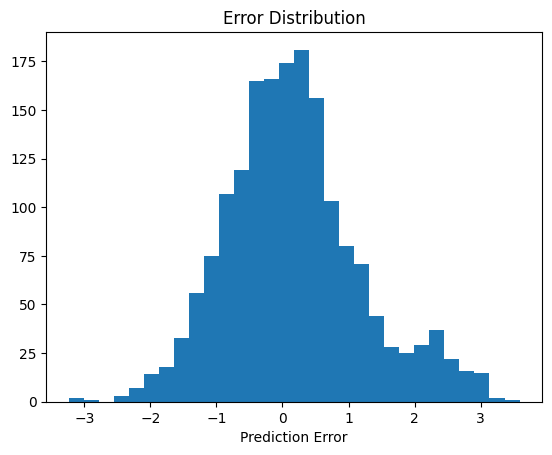

In [25]:
errors = pred_overall - true_overall

plt.hist(errors, bins=30)
plt.title("Error Distribution")
plt.xlabel("Prediction Error")
plt.show()